# Notebook 03: Exploratory Data Analysis

## Overview

This notebook explores through EDA the cleaned disaster-level dataset produced by Notebook 02. Our main goal here is to understand the distribution of the prediction target, identify which features separate the funding tiers, and confirm that the temporal structure of the data justifies our time-based train/test split rather than a random one.

We are saving all charts to the "figures" folder for reference and archiving results. We used the CPI-adjusted dollar amounts for the tier labels to make the comparisons inflation-neutral across the full 1998 to 2026 time span.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#whitegrid + muted palette -> clean academic style for report figures
sns.set_theme(style='whitegrid', palette='muted')

PROCESSED = '../data/processed/'
FIGURES   = '../figures/'
#create figures dir if missing -> avoids savefig errors
os.makedirs(FIGURES, exist_ok=True)

#load cleaned disaster-level data from nb02
disas = pd.read_csv(PROCESSED + 'cleaned_disaster_level.csv', low_memory=False)
print('Disaster-level:', disas.shape)

#shared constants used across all sections
#tier label map -> defined once, reused in 3.3, 3.5, 3.9
TIER_MAP = {0: 'Minor', 1: 'Moderate', 2: 'Major', 3: 'Catastrophic'}

#rdylgn_r -> minor=green (low cost), catastrophic=red (high cost)
TIER_CMAP = 'RdYlGn_r'

#ordered tier labels for axis ticks
TIER_LABELS = [TIER_MAP[i] for i in sorted(TIER_MAP)]

Disaster-level: (1766, 21)


## 3.1 Class Balance: Disaster Funding Tier Distribution

We start by evaluating the distribution of the prediction target across the 4 funding tiers.

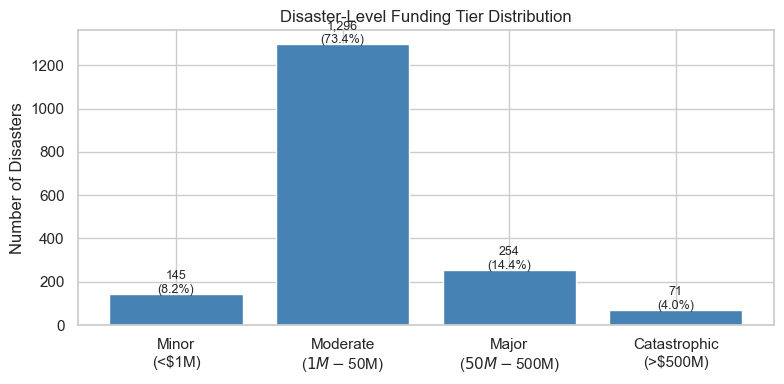

In [2]:
dis_labels = ['Minor\n(<$1M)', 'Moderate\n($1M-$50M)', 'Major\n($50M-$500M)', 'Catastrophic\n(>$500M)']
#count disasters per tier -> sorted by tier index
counts_dis = disas['funding_tier'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dis_labels, counts_dis.values, color='steelblue', edgecolor='white')
ax.set_title('Disaster-Level Funding Tier Distribution')
ax.set_ylabel('Number of Disasters')
#annotate bars with count + percentage
for i, v in enumerate(counts_dis.values):
    ax.text(i, v + 5, f'{v:,}\n({100*v/len(disas):.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES + 'eda_class_balance.png', dpi=150)
plt.show()

We see from the graph that the target variable is severely imbalanced. The "Moderate" tier accounts for 73.4% of all declared disasters, while "Catastrophic" events represent only 4.0%. This skew confirms that using raw accuracy will be highly misleading, confirming our decision to use a weighted F1 score for model evaluation.

## 3.2 Mean Total Federal Share by Incident Type

Here we want to observe how mean federal obligation varies across different events, thus based on "incidentType".

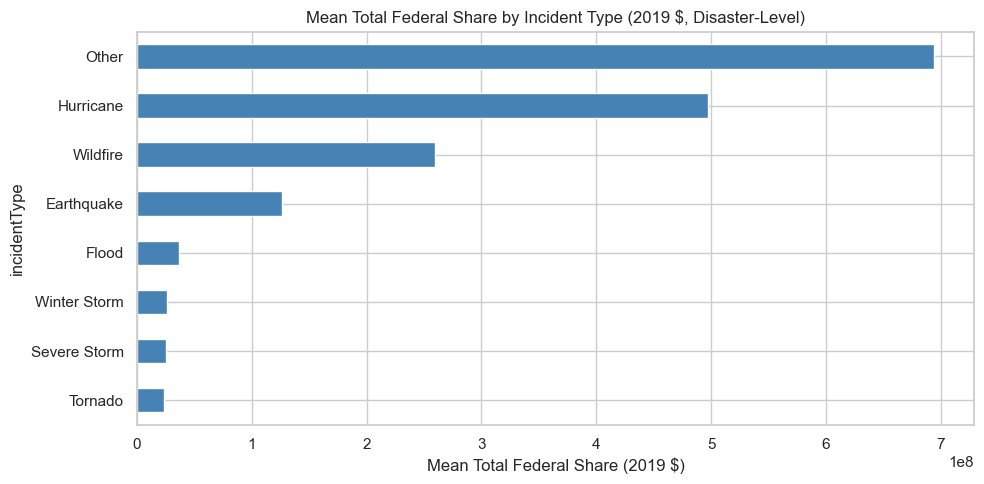

In [3]:
#mean cpi-adjusted obligation per incident type -> sorted descending
avg_by_type = (
    disas.groupby('incidentType')['total_federal_share_2019']
    .mean()
    .sort_values(ascending=False)
)
avg_by_type.plot(kind='barh', figsize=(10, 5), color='steelblue',
                 title='Mean Total Federal Share by Incident Type (2019 $, Disaster-Level)')
plt.xlabel('Mean Total Federal Share (2019 $)')
#invert y-axis -> highest value at top
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES + 'eda_mean_share_by_type.png', dpi=150)
plt.show()

Hazard categories show clear financial separation. "Hurricane" and "Wildfire" drive significantly higher average obligations than routine weather events like "Severe Storm" or "Tornado". The unusually high mean for the "Other" category is likely driven by a small number of massive outlier events, especially the nationwide COVID-19 pandemic declarations.

## 3.3 Funding Tier Distribution by Incident Type

The previous bar chart shows mean obligations, but with means sensitive to a small number of extreme events. This section provides a more informative view: the proportion of disasters in each tier, broken down by incident type.

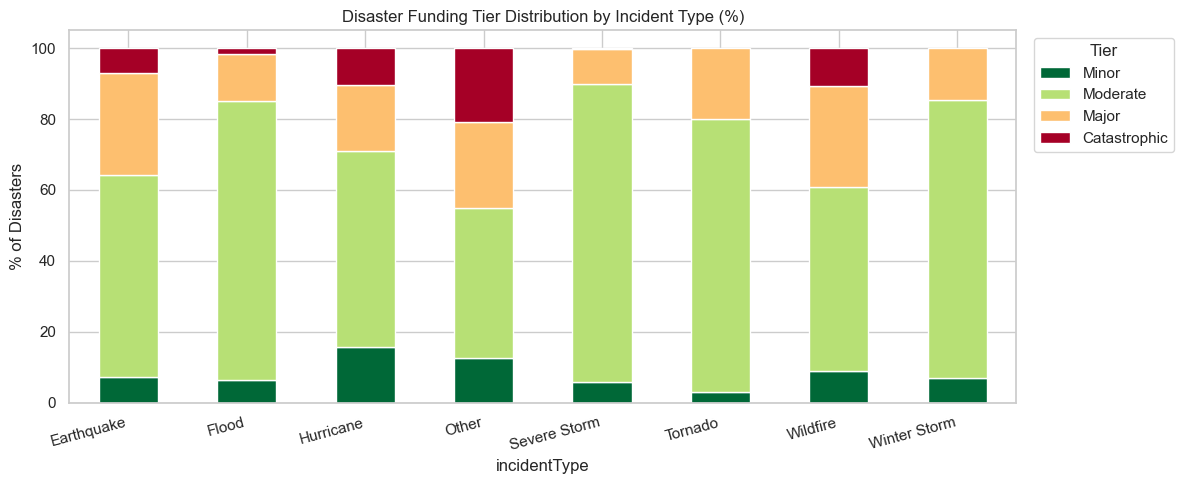

In [4]:
#TIER_MAP defined in setup cell -> do not redefine here
#cross-tabulate incident type x tier -> row-normalise to percentages
ct = (disas.groupby(['incidentType', 'funding_tier'])
          .size()
          .unstack(fill_value=0))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.columns = [TIER_MAP[c] for c in ct_pct.columns]

#rdylgn_r: minor=green (low cost), catastrophic=red (high cost)
ct_pct.plot(kind='bar', stacked=True, figsize=(12, 5),
            colormap=TIER_CMAP, edgecolor='white')
plt.title('Disaster Funding Tier Distribution by Incident Type (%)')
plt.ylabel('% of Disasters')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES + 'eda_tier_by_incident_type.png', dpi=150)
plt.show()

This proportional view confirms that the type of hazard is a strong discriminator for severity. Over 80% of "Severe Storm" and "Tornado" declarations never escalate past the Minor or Moderate tiers. Conversely, "Hurricane" and "Earthquake" events have a substantially higher probability of reaching the Major or Catastrophic tiers.

## 3.4 Total Federal Obligations by Year, Broken Down by Tier

Federal PA spending is not evenly distributed across time. Active hurricane seasons (2004-05, 2017) generate obligation spikes that influence more typical years. Once we noticed this temporal clustering, this led us to opt for a time-based train/validation/test split in notebook 04 rather than a random split, which would distribute hurricane-season observations evenly across train and test thus inflating test performance. A temporal split forces the model to generalise from past years to future years, which is what we found to be the most operationally realistic setting for predicting costs at the moment of declaration.

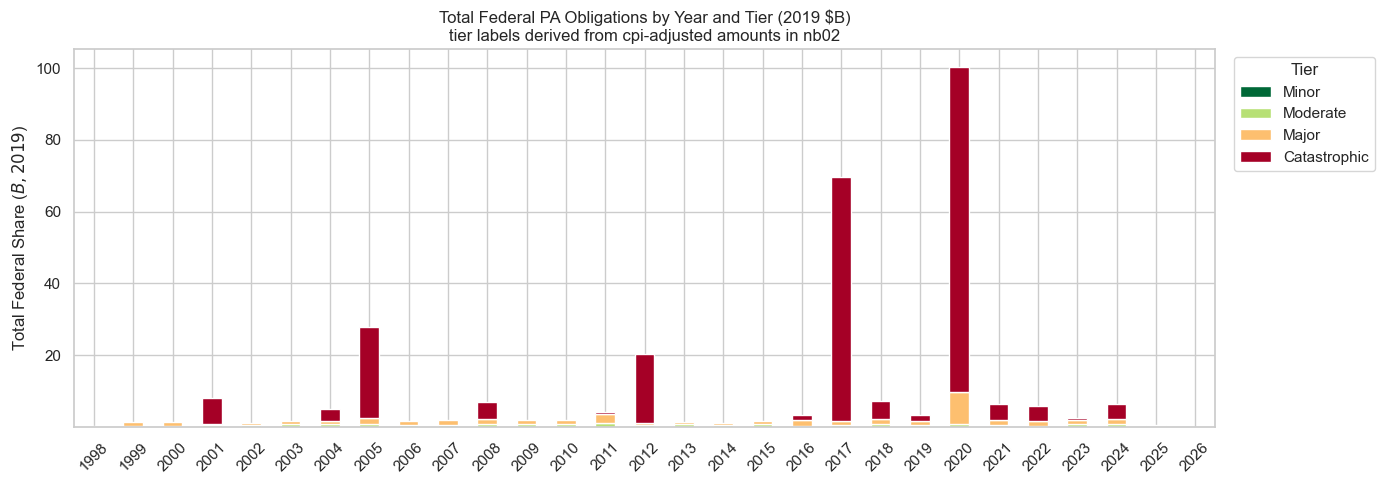

In [5]:
#sum cpi-adjusted obligations by year + tier -> convert to billions
yearly_tier = (
    disas.groupby(['incident_year', 'funding_tier'])['total_federal_share_2019']
    .sum()
    .unstack(fill_value=0)
    / 1e9
)
yearly_tier.columns = [TIER_MAP[c] for c in yearly_tier.columns]

#apply same severity palette as 3.3 -> minor=green, catastrophic=red
cmap_colors = plt.get_cmap('RdYlGn_r')
n_tiers = len(yearly_tier.columns)
tier_colors = [cmap_colors(i / (n_tiers - 1)) for i in range(n_tiers)]

yearly_tier.plot(kind='bar', stacked=True, figsize=(14, 5),
                 color=tier_colors, edgecolor='white')
plt.title(
    'Total Federal PA Obligations by Year and Tier (2019 $B)\n'
    'tier labels derived from cpi-adjusted amounts in nb02'
)
plt.ylabel('Total Federal Share ($B, 2019 $)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.legend(title='Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES + 'eda_obligations_by_year_tier.png', dpi=150)
plt.show()

Federal public assistance spending is extremely volatile and clusters around specific catastrophic years, notably 2005, 2017, and 2020. This visualizes the exact reason a random train/test split would cause data leakage. The extreme temporal clustering validates the use of a time-based split to simulate real-world forecasting conditions.

## 3.5 Disaster Funding Tier Distribution by Season

The season feature shows us the climatic context of a disaster. Fall strongly overlaps with hurricane season, which is naturally associated with high-cost events, while winter produces ice storms and blizzards. If season discriminates funding tier effectively, it carries predictive value beyond what incident type alone provides, because the exact same event category (such as flooding) can occur in any season but produce different severity profiles depending on the ground conditions.

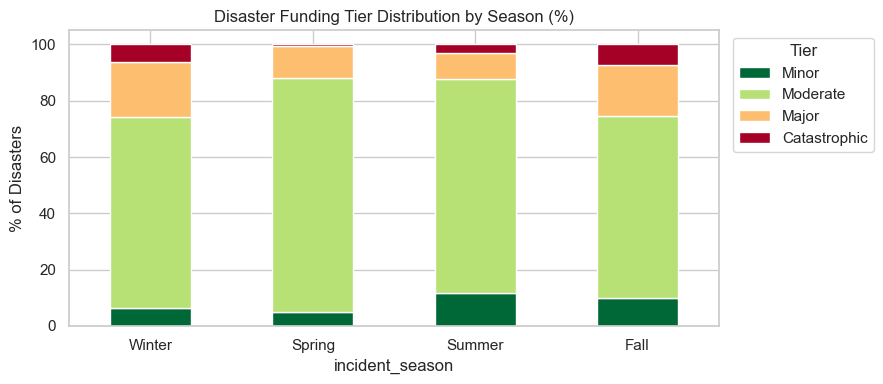

In [6]:
#TIER_MAP + TIER_CMAP defined in setup cell -> do not redefine here
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

#cross-tabulate season x tier -> filter to seasons present in data
ct = (disas.groupby(['incident_season', 'funding_tier'])
          .size()
          .unstack(fill_value=0)
          .loc[[s for s in season_order if s in disas['incident_season'].unique()]])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.columns = [TIER_MAP[c] for c in ct_pct.columns]

#consistent colormap with 3.3 -> rdylgn_r (minor=green, catastrophic=red)
ct_pct.plot(kind='bar', stacked=True, figsize=(9, 4),
            colormap=TIER_CMAP, edgecolor='white')
plt.title('Disaster Funding Tier Distribution by Season (%)')
plt.ylabel('% of Disasters')
plt.xticks(rotation=0)
plt.legend(title='Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES + 'eda_tier_by_season.png', dpi=150)
plt.show()

While the "Moderate" tier dominates year-round, the Fall and Summer seasons show a visibly higher proportion of Catastrophic and Major disasters. This directly aligns with the Atlantic hurricane and Western wildfire seasons, proving that the season feature carries genuine predictive signal beyond just the incident type.

## 3.6 Correlation Heatmap: Numeric Features and Target

We included this correlation heatmap for 2 main reasons:
1. it checks for multicollinearity among the input features. If two features correlate heavily (e.g., above 0.85), keeping both in the model may introduce noise without adding any novel information.
2. it shows the linear relationship between each individual feature and the "funding_tier" target.

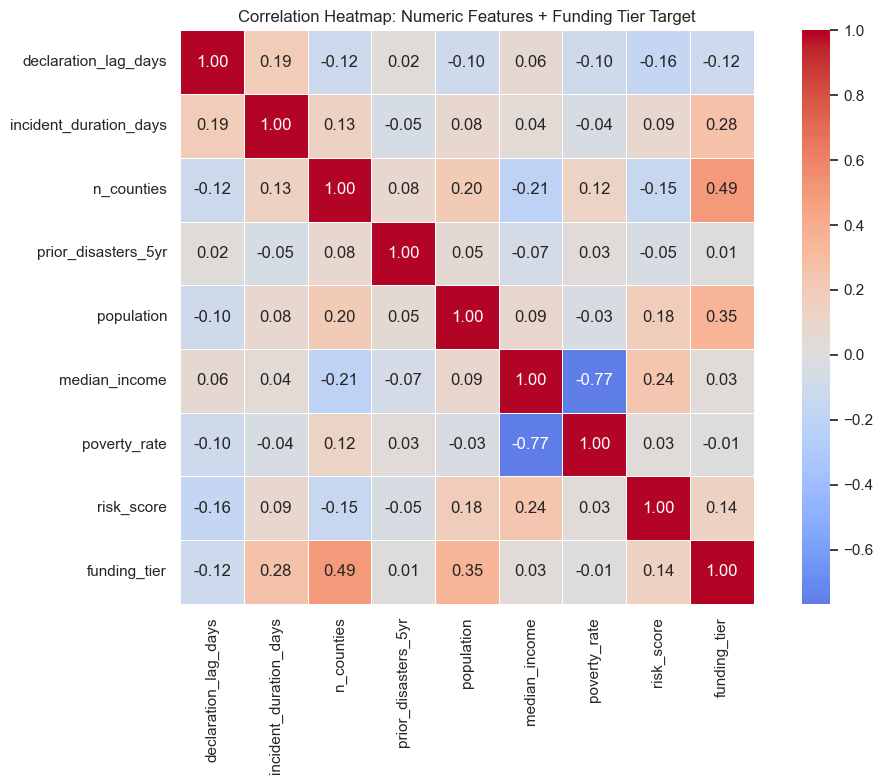

In [7]:
#include funding_tier -> reads feature-to-target correlations directly
num_cols = ['declaration_lag_days', 'incident_duration_days', 'n_counties',
            'prior_disasters_5yr', 'population', 'median_income', 'poverty_rate',
            'risk_score', 'funding_tier']
#filter to cols present in dataset -> safe if any feature was dropped upstream
num_cols = [c for c in num_cols if c in disas.columns]

plt.figure(figsize=(11, 8))
sns.heatmap(disas[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap: Numeric Features + Funding Tier Target')
plt.tight_layout()
plt.savefig(FIGURES + 'eda_correlation_heatmap.png', dpi=150)
plt.show()

Geographic breadth ("n_counties") and "population" show the strongest positive linear correlations with the target variable, at 0.49 and 0.35 respectively. Socioeconomic indicators like "poverty_rate" show near-zero linear correlation, suggesting that their influence on disaster cost is non-linear and will require tree-based models to extract.

## 3.7 Top 10 States by Obligation

States that face frequently major hurricanes or that have exceptionally high populations, accumulate disproportionate funding totals. This section wants to separate frequency effects (how often a state gets hit) from severity effects (how bad it is when they do get hit).

The left panel displays total obligations, which inherently favors states with many disaster declarations. The right panel shows the mean obligation per disaster, revealing which states tend to produce individually massive events regardless of how frequently they declare.

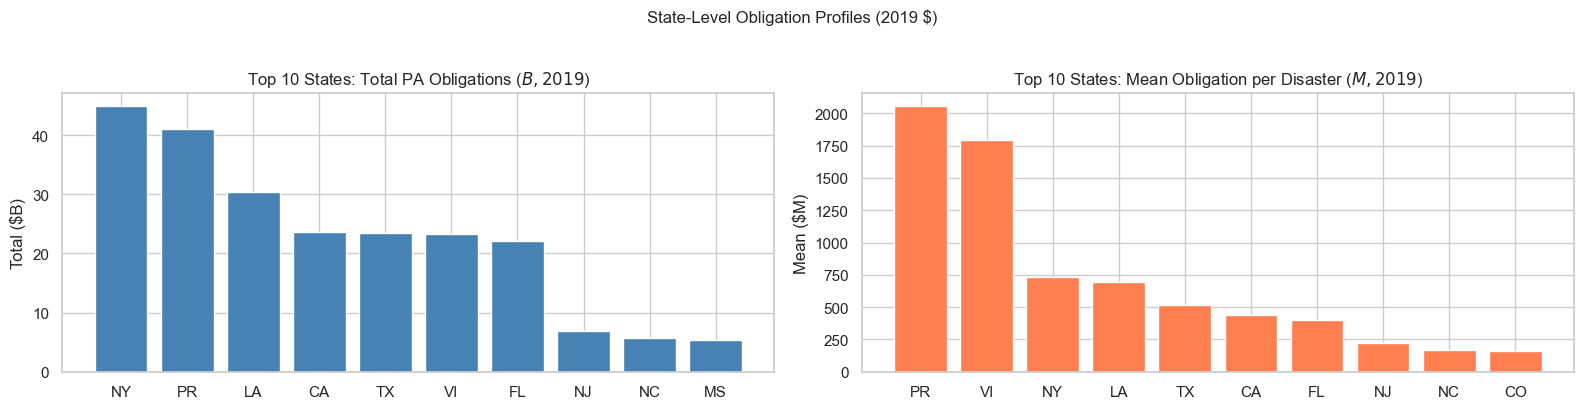

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

#left panel: total obligations by state -> frequency + severity combined
top_total = (
    disas.groupby('stateAbbreviation')['total_federal_share_2019']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    / 1e9
)
axes[0].bar(top_total.index, top_total.values, color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 States: Total PA Obligations ($B, 2019 $)')
axes[0].set_ylabel('Total ($B)')
axes[0].tick_params(axis='x', rotation=0)

#right panel: mean per disaster -> removes frequency bias, shows severity
top_mean = (
    disas.groupby('stateAbbreviation')['total_federal_share_2019']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    / 1e6
)
axes[1].bar(top_mean.index, top_mean.values, color='coral', edgecolor='white')
axes[1].set_title('Top 10 States: Mean Obligation per Disaster ($M, 2019 $)')
axes[1].set_ylabel('Mean ($M)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('State-Level Obligation Profiles (2019 $)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES + 'eda_top_states.png', dpi=150)
plt.show()

Comparing total obligations to mean obligations shows us quite a big difference in geographic risk profiles. While populous mainland states like New York and California rank highly in total historical spending due to a high frequency of events, US territories like Puerto Rico and the Virgin Islands completely dominate the mean obligation per disaster. This highlights that while mainland states experience many lower-tier events, disasters that strike the territories are disproportionately severe and financially devastating on a per-event basis.

## 3.8 Missing Data Check

A final null check confirms that notebook 02 cleaned all records successfully.

In [9]:
#check for any remaining nulls -> should be zero after nb02 cleaning
missing = disas.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    print('Remaining nulls in disaster-level data:')
    print(missing)
else:
    print('No nulls remaining in disaster-level data. ✓')

No nulls remaining in disaster-level data. ✓


## 3.9 Numeric Feature Distributions by Funding Tier

These box plots visualize how each numeric feature is distributed across the three modeled tiers (Minor, Moderate, Major), with Catastrophic included for full context. Unlike the correlation heatmap, which only shows strict linear relationships, these box plots clearly reveal the differences in medians, spread, and outlier structures.

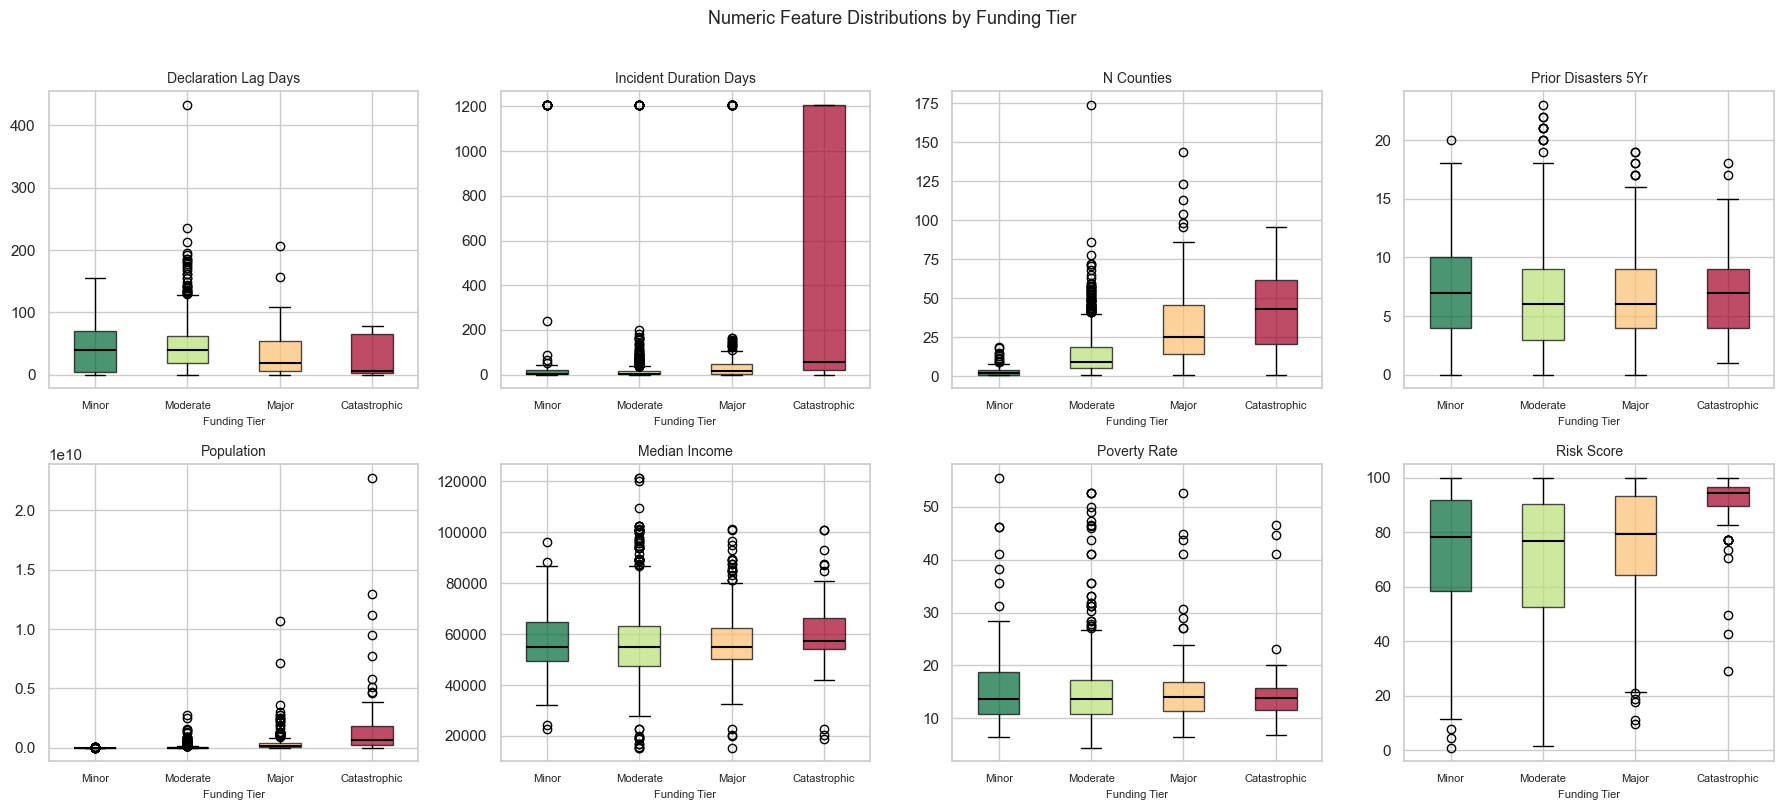

In [10]:
feat_cols = ['declaration_lag_days', 'incident_duration_days', 'n_counties',
             'prior_disasters_5yr', 'population', 'median_income',
             'poverty_rate', 'risk_score']
#filter to cols present -> safe against upstream changes
feat_cols = [c for c in feat_cols if c in disas.columns]

tier_order  = sorted(disas['funding_tier'].unique())
tick_labels = [TIER_MAP[t] for t in tier_order]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    #extract values per tier -> list of arrays for boxplot
    data_by_tier = [disas.loc[disas['funding_tier'] == t, col].dropna().values
                    for t in tier_order]
    bp = axes[i].boxplot(data_by_tier, patch_artist=True, notch=False,
                         medianprops=dict(color='black', linewidth=1.5))
    #apply severity colormap: minor=green, catastrophic=red (rdylgn_r)
    cmap_fn = plt.get_cmap('RdYlGn_r')
    for patch, idx in zip(bp['boxes'], range(len(tier_order))):
        patch.set_facecolor(cmap_fn(idx / max(len(tier_order) - 1, 1)))
        patch.set_alpha(0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xticks(range(1, len(tier_order) + 1))
    axes[i].set_xticklabels(tick_labels, fontsize=8)
    axes[i].set_xlabel('Funding Tier', fontsize=8)

plt.suptitle('Numeric Feature Distributions by Funding Tier', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + 'eda_features_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

The box plots clearly shows us that higher funding tiers are structurally associated with larger population footprints, higher baseline risk scores, and a greater number of affected counties. The extreme outliers visible in "incident_duration_days" within the Catastrophic tier further highlight the unique administrative footprint of multi-year crisis events.